# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('/content/listings.csv')
display(df.head())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,44701,https://www.airbnb.com/rooms/44701,20250620182418,2025-06-20,city scrape,"Jan 4-11,2026 CES: 2beds,2baths, 1020 sqft,sle...",Experience the luxury of our well-appointed vi...,This 19.5-acre gated community is 1 block from...,https://a0.muscache.com/pictures/1218626b-295f...,189245,...,5.00,4.75,4.50,NaN,f,2,2,0,0,0.04
1,113019,https://www.airbnb.com/rooms/113019,20250620182418,2025-06-21,city scrape,MGM Signature Studio !,"*3 night minimum, MAY accept two night stay on...",NaN,https://a0.muscache.com/pictures/56149560/d180...,575684,...,4.44,4.81,4.61,NaN,f,11,10,1,0,1.22
2,114140,https://www.airbnb.com/rooms/114140,20250620182418,2025-06-21,city scrape,MGM Signature 1BR/2BA Suite W/ View,"*3 night minimum, will accept 2 nights on occa...",NaN,https://a0.muscache.com/pictures/56068170/7fa6...,575684,...,4.41,4.77,4.64,NaN,f,11,10,1,0,1.03
3,133084,https://www.airbnb.com/rooms/133084,20250620182418,2025-06-21,city scrape,"Beautiful, Sleek, Sexy Condo - Long Term Rental","This immaculate, modern loft is available for ...",NaN,https://a0.muscache.com/pictures/30c3a88e-3c4b...,653641,...,5.00,4.50,5.00,NaN,t,1,1,0,0,0.01
4,143096,https://www.airbnb.com/rooms/143096,20250620182418,2025-06-20,city scrape,Furnished Las Vegas House with Pool,"Renting entire 2,000 square feet home, 3 bedro...",The neighborhood is quiet and family oriented.,https://a0.muscache.com/pictures/904198/63350b...,694506,...,4.89,4.77,4.70,NaN,f,1,1,0,0,1.49


## 2. Explore Missing Values

Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

### In your markdown:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?



Columns with null values:
description                       188
neighborhood_overview           10936
host_name                           3
host_since                          3
host_location                    4709
host_about                       7751
host_response_time               1659
host_response_rate               1659
host_acceptance_rate             1086
host_is_superhost                 497
host_thumbnail_url                  3
host_picture_url                    3
host_neighbourhood               7593
host_listings_count                 3
host_total_listings_count           3
host_verifications                  3
host_has_profile_pic                3
host_identity_verified              3
neighbourhood                   10936
neighbourhood_group_cleansed    17891
bathrooms                        4905
bathrooms_text                    122
bedrooms                          733
beds                             4906
price                            4906
calendar_updated        

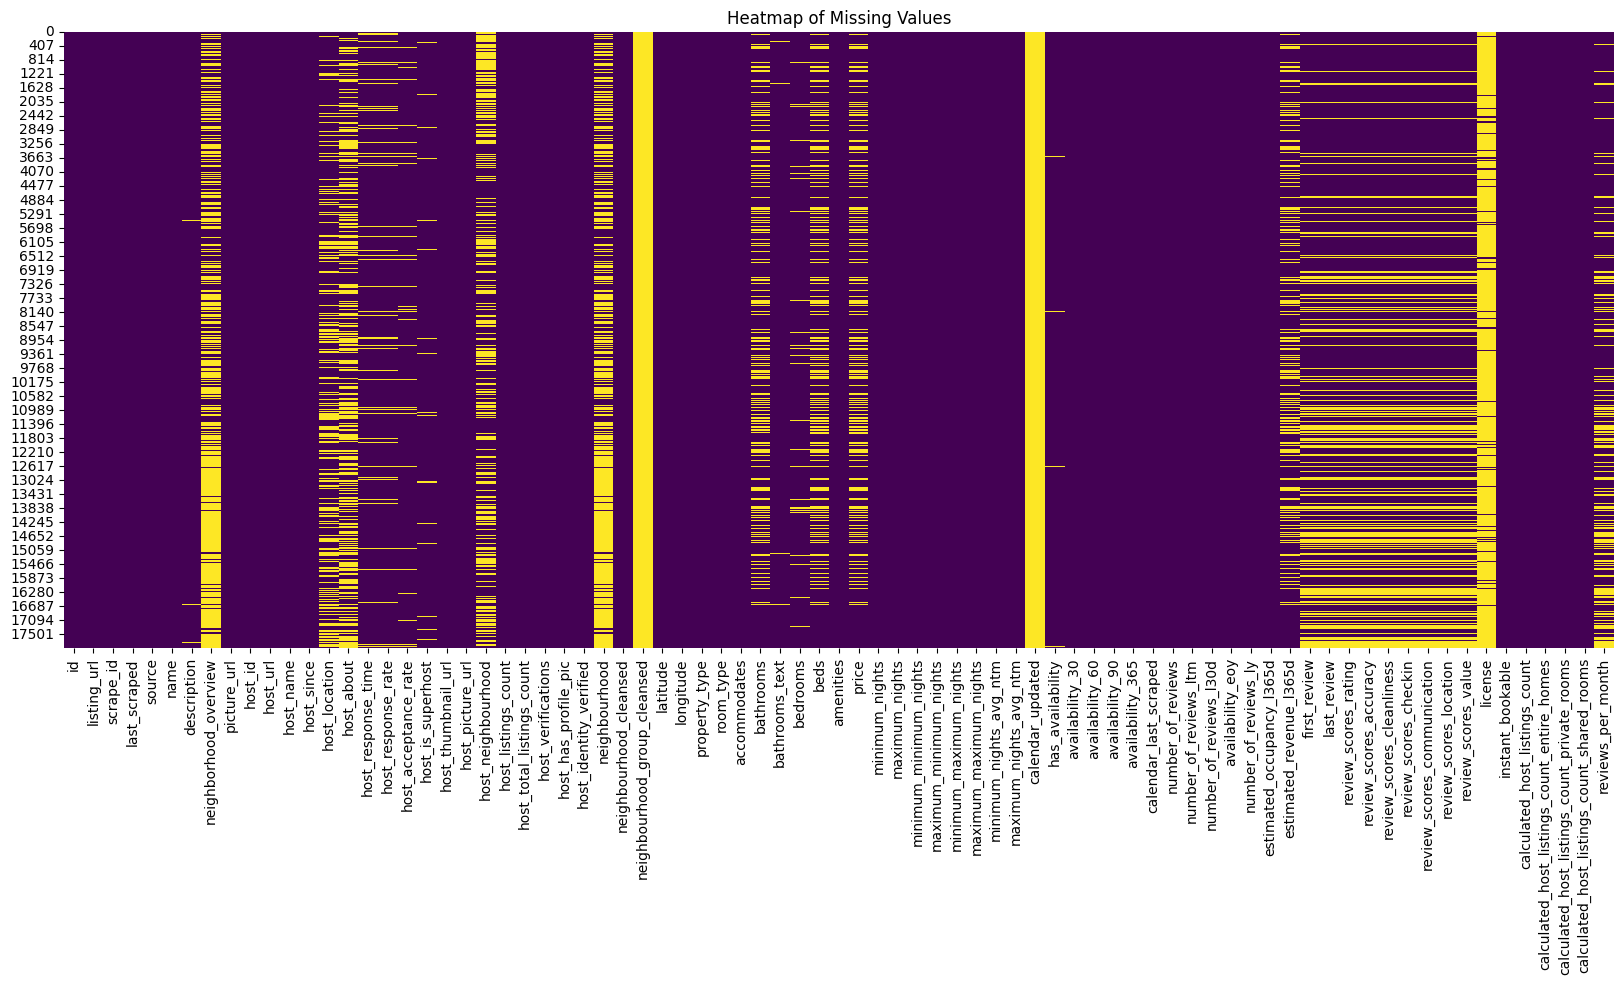

In [6]:
# Count null values for each column
null_counts = df.isnull().sum()

# Display columns with null values
print("Columns with null values:")
print(null_counts[null_counts > 0])

# Create a heatmap to visualize missing values
plt.figure(figsize=(20, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

1. The top 3 columns with the most missing values are 'neighbourhood_group_cleansed', 'calendar_updated', and 'license'.
2. Missing values in the columns like 'price', 'bedrooms', and 'beds', would create business issues because they are important for pricing and filtering listings.
3. Columns with a high number of missing values like 'neighbourhood_group_cleansed','calendar_updated', and 'license' could be removed as the information is not as relevant to the analysis of the data.

## 3. Drop Columns That Aren’t Useful

Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

### In Your Response:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?



In [10]:
columns_to_drop = [
    'neighbourhood_group_cleansed',
    'calendar_updated',
    'license',
    'host_about',
    'description',
    'neighborhood_overview'
]

# Filter out columns that don't exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

df = df.drop(columns=existing_columns_to_drop)

# Confirm columns are dropped
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17891 entries, 0 to 17890
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            17891 non-null  int64  
 1   listing_url                                   17891 non-null  object 
 2   scrape_id                                     17891 non-null  int64  
 3   last_scraped                                  17891 non-null  object 
 4   source                                        17891 non-null  object 
 5   name                                          17891 non-null  object 
 6   picture_url                                   17891 non-null  object 
 7   host_id                                       17891 non-null  int64  
 8   host_url                                      17891 non-null  object 
 9   host_name                                     17888 non-null 

1. I dropped neighbourhood_group_cleansed, calendar_updated, license, host_about, description, and neighborhood_overview.

2. These were not useful from a business perspective because a lot of them did not provide as much value as columns lice price and bedrooms does. Columns like calendar had a lot of missing values that simply were not necessary for the analysis that we are performing.

3. If let in, the data could become overwhelming or potentially be skewed.



## 4. Fill or Fix Values in Key Columns

Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

### In your response:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

In [12]:
# Fill missing values in 'price' and 'beds' columns with "unknown"
df['price'] = df['price'].fillna('unknown')
df['beds'] = df['beds'].fillna('unknown')

# Verify the changes by checking for null values in these columns
print("Missing values in 'price' after filling:", df['price'].isnull().sum())
print("Missing values in 'beds' after filling:", df['beds'].isnull().sum())

Missing values in 'price' after filling: 0
Missing values in 'beds' after filling: 0


1. The two columns that I cleaned were price and beds,

2. I decided to replace the missing values in each of the columns with "unknown" in order to maintain the intergrity of the numerical data in each column.

3. The risk with that method is some potential compatability issues if we decide to use this data for modeling later.


## 5. Convert and Clean Data Types

Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

### In Your Response: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?


In [13]:
# Clean and convert the 'price' column
# Remove '$' and ',' from the 'price' column and convert to numeric
# Handle the "unknown" values by converting them to NaN
df['price'] = df['price'].astype(str).str.replace('[$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Check the data type and summarize the cleaned column
print("Data type of 'price' after cleaning:", df['price'].dtype)
display(df['price'].describe())

Data type of 'price' after cleaning: float64


,price
count,12985.000000
mean,606.215787
std,3677.899883
min,8.000000
25%,85.000000
50%,146.000000
75%,242.000000
max,114138.000000


1. The column fixed was price.

2. The cleaning steps that I used were converting the column to a string type so that I can use the string methods, then I removed the dollar signs and the commas, and converted the cleaned values to a numerical data type.

3. This helps prepare the data for later use by allowing for numerical analysis with the price column. With the data as numbers, calculations can now be performed like finding the average and median.

## 6. Remove Duplicate Records

Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

### In your markdown:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?


In [14]:
# Check for exact duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_rows}")

# Check for duplicate IDs in the 'id' column
duplicate_ids = df['id'].duplicated().sum()
print(f"Number of duplicate IDs: {duplicate_ids}")

# Remove exact duplicate rows
if duplicate_rows > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicate_rows} exact duplicate rows.")

# Note: We are not removing rows with duplicate IDs here, as a single listing ID might appear
# multiple times due to different scrape dates or other factors depending on the dataset source.
# The focus here is on exact duplicate rows.

# Verify that exact duplicate rows are removed
print(f"Number of rows after removing duplicates: {len(df)}")

Number of exact duplicate rows: 0
Number of duplicate IDs: 0
Number of rows after removing duplicates: 17891


1. No duplicate rows were found.

2. Since no duplicates were found, the decision of whether or not to keep or drop did not need to be made. If there were duplicates, I could use the drop_duplicates() function.

3. Duplicates are risky for Airbnb teams because they can lead to inflated numbers like the total number of properties that are actually available. It can also cause inaccurate analysis with modeling later.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [15]:
df.to_csv("cleaned_airbnb_data.csv", index=False)

## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### In your markdown:
1. What was the most surprising or challenging part of cleaning this dataset?
2. How did you decide which data to drop, fix, or keep?
3. What’s one way a business team (e.g., hosts, pricing analysts, platform ops) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


1. The most challenging part of cleaning this dataset was deciding how to handle columns with a large number of missing values. The initial zip error was also a surprising challenge.
2. I decided which data to drop primarily based on the percentage of missing values; columns with a very high percentage were strong candidates for dropping as they provided limited information. For columns with fewer missing values, I chose to fill them, initially with "unknown" as requested, but ideally with a numerical placeholder.
3. A business team, such as pricing analysts, could significantly benefit from the cleaned version of this data. With the 'price' column correctly formatted as a number and fewer missing values in key fields, they can perform more accurate analysis to understand pricing trends.
4. If I had more time, I would explore more sophisticated imputation techniques for numerical columns with missing values like 'beds'.
5. This relates to my customized learnign outcome I created by helping me understand basic data analysis, and using it to help understand real-world situations.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [16]:
!jupyter nbconvert --to html "assignment_06_BensonDallin.ipynb"

[NbConvertApp] Converting notebook assignment_06_BensonDallin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 596984 bytes to assignment_06_BensonDallin.html
